
PHASE KICKBACK AND BINARY CLASSIFICATION

Concept:

Input data
    |
    v
Quantum encoding
    |
    v
Oracle evaluates f(x)
    |
    v
Phase kickback
    |
    v
Quantum interference
    |
    v
Classification: 0 or 1

TRAINING DATA
Input = 0.1  -> Class = 0
Input = 0.2  -> Class = 0
Input = 0.3  -> Class = 0
Input = 0.7  -> Class = 1
Input = 0.8  -> Class = 1
Input = 0.9  -> Class = 1

CLASSIFICATION RESULTS
Input = 0.1 | Actual = 0 | Predicted = 0
Input = 0.2 | Actual = 0 | Predicted = 0
Input = 0.3 | Actual = 0 | Predicted = 0
Input = 0.7 | Actual = 1 | Predicted = 1
Input = 0.8 | Actual = 1 | Predicted = 1
Input = 0.9 | Actual = 1 | Predicted = 1

Classification Accuracy = 100.00%

QUANTUM PHASE-KICKBACK CIRCUIT
     ┌───┐          ┌───┐
q_0: ┤ H ├───────■──┤ H ├
     ├───┤┌───┐┌─┴─┐└───┘
q_1: ┤ X ├┤ H ├┤ X ├─────
     └───┘└───┘└───┘     

Final Statevector:
Statevector([ 2.29934717e-17+0.j,  7.07106781e-01+0.j, -2.29934717e-17+0.j,
             -7.07106781e-01+0.j],
         

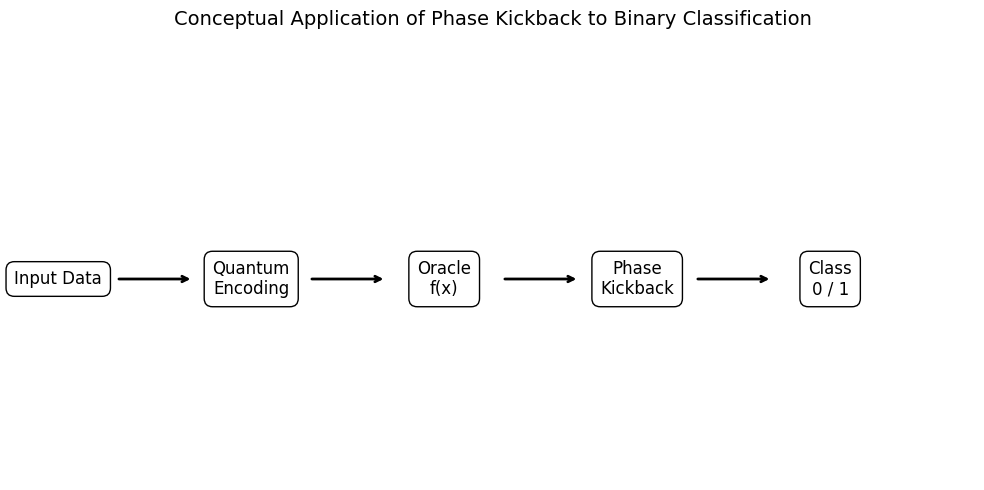

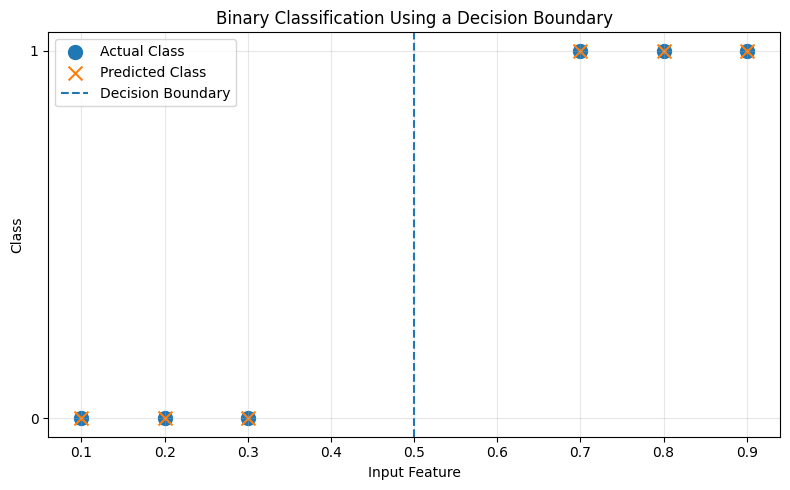

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ---------------------------------------------------------
# PHASE KICKBACK - BINARY CLASSIFICATION
# ---------------------------------------------------------

print("\nPHASE KICKBACK AND BINARY CLASSIFICATION")
print("=" * 70)

print("""
Concept:

Input data
    |
    v
Quantum encoding
    |
    v
Oracle evaluates f(x)
    |
    v
Phase kickback
    |
    v
Quantum interference
    |
    v
Classification: 0 or 1
""")

# ---------------------------------------------------------
# EXAMPLE CLASSIFICATION
# ---------------------------------------------------------

data = np.array([
    0.1,
    0.2,
    0.3,
    0.7,
    0.8,
    0.9
])

labels = np.array([
    0,
    0,
    0,
    1,
    1,
    1
])

print("TRAINING DATA")
print("=" * 70)

for x, label in zip(data, labels):
    print(f"Input = {x:.1f}  -> Class = {label}")

# ---------------------------------------------------------
# SIMPLE THRESHOLD CLASSIFIER
# ---------------------------------------------------------

threshold = 0.5

predictions = []

for x in data:

    if x < threshold:
        predictions.append(0)
    else:
        predictions.append(1)

predictions = np.array(predictions)

accuracy = np.mean(predictions == labels)

print("\nCLASSIFICATION RESULTS")
print("=" * 70)

for x, actual, predicted in zip(
    data,
    labels,
    predictions
):
    print(
        f"Input = {x:.1f} | "
        f"Actual = {actual} | "
        f"Predicted = {predicted}"
    )

print(f"\nClassification Accuracy = {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# QUANTUM PHASE KICKBACK CIRCUIT
# ---------------------------------------------------------

qc = QuantumCircuit(2)

qc.x(1)
qc.h(0)
qc.h(1)

# Balanced oracle
qc.cx(0, 1)

qc.h(0)

print("\nQUANTUM PHASE-KICKBACK CIRCUIT")
print("=" * 70)
print(qc.draw())

state = Statevector.from_instruction(qc)

print("\nFinal Statevector:")
print(state)

# ---------------------------------------------------------
# VISUAL DIAGRAM
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.axis("off")

boxes = [
    (0.05, 0.45, "Input Data"),
    (0.25, 0.45, "Quantum\nEncoding"),
    (0.45, 0.45, "Oracle\nf(x)"),
    (0.65, 0.45, "Phase\nKickback"),
    (0.85, 0.45, "Class\n0 / 1")
]

for x, y, text in boxes:

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(
            boxstyle="round,pad=0.5",
            edgecolor="black",
            facecolor="white"
        ),
        transform=ax.transAxes
    )

for i in range(len(boxes) - 1):

    x1 = boxes[i][0] + 0.06
    x2 = boxes[i + 1][0] - 0.06

    ax.annotate(
        "",
        xy=(x2, 0.45),
        xytext=(x1, 0.45),
        xycoords=ax.transAxes,
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        )
    )

ax.set_title(
    "Conceptual Application of Phase Kickback to Binary Classification",
    fontsize=14
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CLASSIFICATION GRAPH
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    data,
    labels,
    s=100,
    label="Actual Class"
)

plt.scatter(
    data,
    predictions,
    marker="x",
    s=100,
    label="Predicted Class"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Decision Boundary"
)

plt.xlabel("Input Feature")
plt.ylabel("Class")
plt.title("Binary Classification Using a Decision Boundary")

plt.yticks([0, 1])

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()